In [1]:
"""
6.1 Understanding Decision Tree
Perhitungan Entropy dan Gini Impurity dengan scikit-learn

Dataset ilustratif (bertema sama dengan artikel Towards Data Science:
"Decision Trees Explained: Entropy, Information Gain, Gini Index, CCP Pruning"):
15 mahasiswa mengikuti ujian online ML -> target: Pass / Fail
Fitur: Working Status, Online Courses, Student Background

Teknik pembacaan struktur tree (tree_.impurity, children_left/right, feature,
threshold, value) mengikuti contoh resmi scikit-learn:
"Understanding the decision tree structure"
https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
import matplotlib.pyplot as plt

In [2]:
# ---------------------------------------------------------------------------
# 1. Dataset (15 baris, meniru studi kasus pada artikel)
# ---------------------------------------------------------------------------
data = [
    # WorkingStatus, OnlineCourses, Background, Result
    ("Working",    "Yes", "CS",     "Pass"),
    ("Working",    "No",  "CS",     "Pass"),
    ("NotWorking", "Yes", "CS",     "Pass"),
    ("NotWorking", "No",  "CS",     "Pass"),
    ("Working",    "Yes", "Others", "Fail"),
    ("Working",    "No",  "Others", "Fail"),
    ("NotWorking", "Yes", "Others", "Fail"),
    ("NotWorking", "No",  "Others", "Fail"),
    ("Working",    "Yes", "Maths",  "Pass"),
    ("Working",    "No",  "Maths",  "Pass"),
    ("Working",    "Yes", "Maths",  "Fail"),
    ("Working",    "No",  "Maths",  "Fail"),
    ("NotWorking", "Yes", "Maths",  "Pass"),
    ("NotWorking", "No",  "Maths",  "Pass"),
    ("NotWorking", "Yes", "Maths",  "Pass"),
]
df = pd.DataFrame(data, columns=["WorkingStatus", "OnlineCourses", "Background", "Result"])
print("Dataset:")
print(df)
print("\nDistribusi target:")
print(df["Result"].value_counts(), "\n")

Dataset:
   WorkingStatus OnlineCourses Background Result
0        Working           Yes         CS   Pass
1        Working            No         CS   Pass
2     NotWorking           Yes         CS   Pass
3     NotWorking            No         CS   Pass
4        Working           Yes     Others   Fail
5        Working            No     Others   Fail
6     NotWorking           Yes     Others   Fail
7     NotWorking            No     Others   Fail
8        Working           Yes      Maths   Pass
9        Working            No      Maths   Pass
10       Working           Yes      Maths   Fail
11       Working            No      Maths   Fail
12    NotWorking           Yes      Maths   Pass
13    NotWorking            No      Maths   Pass
14    NotWorking           Yes      Maths   Pass

Distribusi target:
Result
Pass    9
Fail    6
Name: count, dtype: int64 



In [3]:
# ---------------------------------------------------------------------------
# 2. Encoding fitur kategorikal -> numerik (Decision Tree sklearn butuh numerik)
# ---------------------------------------------------------------------------
X_cols = ["WorkingStatus", "OnlineCourses", "Background"]
enc = OrdinalEncoder()
X = enc.fit_transform(df[X_cols])
y = df["Result"].values
feature_names = X_cols
print("Kategori tiap fitur (urutan sesuai kode numerik hasil encoding):")
for col, cats in zip(X_cols, enc.categories_):
    print(f"  {col}: {list(cats)}")
print()

Kategori tiap fitur (urutan sesuai kode numerik hasil encoding):
  WorkingStatus: ['NotWorking', 'Working']
  OnlineCourses: ['No', 'Yes']
  Background: ['CS', 'Maths', 'Others']



In [4]:
# ---------------------------------------------------------------------------
# 3. Fungsi manual Entropy & Gini (untuk verifikasi terhadap sklearn)
# ---------------------------------------------------------------------------
def entropy_manual(counts):
    counts = np.array(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())

def gini_manual(counts):
    counts = np.array(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    return float(1 - (p ** 2).sum())

pass_count = (y == "Pass").sum()
fail_count = (y == "Fail").sum()
print(f"Cek manual node akar -> Pass={pass_count}, Fail={fail_count}")
print(f"  Entropy manual : {entropy_manual([pass_count, fail_count]):.4f}")
print(f"  Gini manual    : {gini_manual([pass_count, fail_count]):.4f}\n")


Cek manual node akar -> Pass=9, Fail=6
  Entropy manual : 0.9710
  Gini manual    : 0.4800



In [5]:
# ---------------------------------------------------------------------------
# 4. Fit dua Decision Tree: criterion='entropy' dan criterion='gini'
# ---------------------------------------------------------------------------
clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=0)
clf_entropy.fit(X, y)

clf_gini = DecisionTreeClassifier(criterion="gini", random_state=0)
clf_gini.fit(X, y)


def unveil_tree(clf, criterion_name):
    """Menelusuri struktur tree_ persis seperti contoh sklearn
    'Understanding the decision tree structure', lalu memverifikasi
    setiap nilai impurity dengan fungsi manual."""
    t = clf.tree_
    n_nodes = t.node_count
    children_left = t.children_left
    children_right = t.children_right
    feature = t.feature
    threshold = t.threshold
    impurity = t.impurity
    n_node_samples = t.n_node_samples
    weighted_n_node_samples = t.weighted_n_node_samples
    # tree_.value menyimpan PROPORSI kelas per node (bukan jumlah mentah);
    # dikalikan weighted_n_node_samples untuk mendapatkan jumlah sampel aktual
    # (lihat contoh resmi sklearn "Understanding the decision tree structure").
    value = t.value * weighted_n_node_samples[:, None, None]  # shape (n_nodes, 1, n_classes)
    classes = clf.classes_  # urutan kelas, misal ['Fail' 'Pass']

    node_depth = np.zeros(n_nodes, dtype=np.int64)
    is_leaf = np.zeros(n_nodes, dtype=bool)
    stack = [(0, 0)]
    while stack:
        node_id, depth = stack.pop()
        node_depth[node_id] = depth
        if children_left[node_id] != children_right[node_id]:
            stack.append((children_left[node_id], depth + 1))
            stack.append((children_right[node_id], depth + 1))
        else:
            is_leaf[node_id] = True

    print(f"===== DecisionTreeClassifier(criterion='{criterion_name}') =====")
    print(f"Jumlah node: {n_nodes} | classes_ = {list(classes)}\n")

    for i in range(n_nodes):
        counts = np.round(value[i, 0]).astype(float)  # jumlah sampel tiap kelas di node i
        indent = "    " * node_depth[i]
        manual_val = (entropy_manual(counts) if criterion_name == "entropy"
                      else gini_manual(counts))
        if is_leaf[i]:
            pred = classes[np.argmax(counts)]
            print(f"{indent}Node {i} [LEAF]  n_samples={n_node_samples[i]:>2} "
                  f"counts={dict(zip(classes, counts.astype(int)))} "
                  f"-> prediksi: {pred}")
            print(f"{indent}   impurity(sklearn)={impurity[i]:.4f}  "
                  f"impurity(manual)={manual_val:.4f}")
        else:
            fname = feature_names[feature[i]]
            print(f"{indent}Node {i} [SPLIT] n_samples={n_node_samples[i]:>2} "
                  f"counts={dict(zip(classes, counts.astype(int)))}")
            print(f"{indent}   impurity(sklearn)={impurity[i]:.4f}  "
                  f"impurity(manual)={manual_val:.4f}")
            print(f"{indent}   split: {fname} (kode) <= {threshold[i]:.2f} "
                  f"-> kiri=Node {children_left[i]}, kanan=Node {children_right[i]}")
        print()
    return


unveil_tree(clf_entropy, "entropy")
unveil_tree(clf_gini, "gini")



===== DecisionTreeClassifier(criterion='entropy') =====
Jumlah node: 9 | classes_ = ['Fail', 'Pass']

Node 0 [SPLIT] n_samples=15 counts={'Fail': 90, 'Pass': 135}
   impurity(sklearn)=0.9710  impurity(manual)=0.9710
   split: Background (kode) <= 1.50 -> kiri=Node 1, kanan=Node 8

    Node 1 [SPLIT] n_samples=11 counts={'Fail': 22, 'Pass': 99}
       impurity(sklearn)=0.6840  impurity(manual)=0.6840
       split: WorkingStatus (kode) <= 0.50 -> kiri=Node 2, kanan=Node 3

        Node 2 [LEAF]  n_samples= 5 counts={'Fail': 0, 'Pass': 25} -> prediksi: Pass
           impurity(sklearn)=0.0000  impurity(manual)=-0.0000

        Node 3 [SPLIT] n_samples= 6 counts={'Fail': 12, 'Pass': 24}
           impurity(sklearn)=0.9183  impurity(manual)=0.9183
           split: Background (kode) <= 0.50 -> kiri=Node 4, kanan=Node 5

            Node 4 [LEAF]  n_samples= 2 counts={'Fail': 0, 'Pass': 4} -> prediksi: Pass
               impurity(sklearn)=0.0000  impurity(manual)=-0.0000

            Node 5

In [6]:
# ---------------------------------------------------------------------------
# 5. Information Gain pada root node untuk masing-masing kriteria
# ---------------------------------------------------------------------------
def information_gain(clf, node=0):
    t = clf.tree_
    left, right = t.children_left[node], t.children_right[node]
    n_parent = t.n_node_samples[node]
    n_left, n_right = t.n_node_samples[left], t.n_node_samples[right]
    ig = t.impurity[node] - (n_left / n_parent * t.impurity[left]
                              + n_right / n_parent * t.impurity[right])
    return ig

print("Information Gain (pengurangan impurity) pada root node:")
print(f"  Kriteria entropy -> IG = {information_gain(clf_entropy):.4f}")
print(f"  Kriteria gini    -> IG = {information_gain(clf_gini):.4f}\n")



Information Gain (pengurangan impurity) pada root node:
  Kriteria entropy -> IG = 0.4693
  Kriteria gini    -> IG = 0.2618



In [7]:
# ---------------------------------------------------------------------------
# 6. Feature importance (berbasis pengurangan impurity)
# ---------------------------------------------------------------------------
print("Feature importances (criterion='entropy'):")
for f, imp in zip(feature_names, clf_entropy.feature_importances_):
    print(f"  {f}: {imp:.4f}")
print("\nFeature importances (criterion='gini'):")
for f, imp in zip(feature_names, clf_gini.feature_importances_):
    print(f"  {f}: {imp:.4f}")



Feature importances (criterion='entropy'):
  WorkingStatus: 0.1907
  OnlineCourses: 0.0000
  Background: 0.8093

Feature importances (criterion='gini'):
  WorkingStatus: 0.1166
  OnlineCourses: 0.0000
  Background: 0.8834



Gambar tree tersimpan: decision_tree_entropy_vs_gini.png


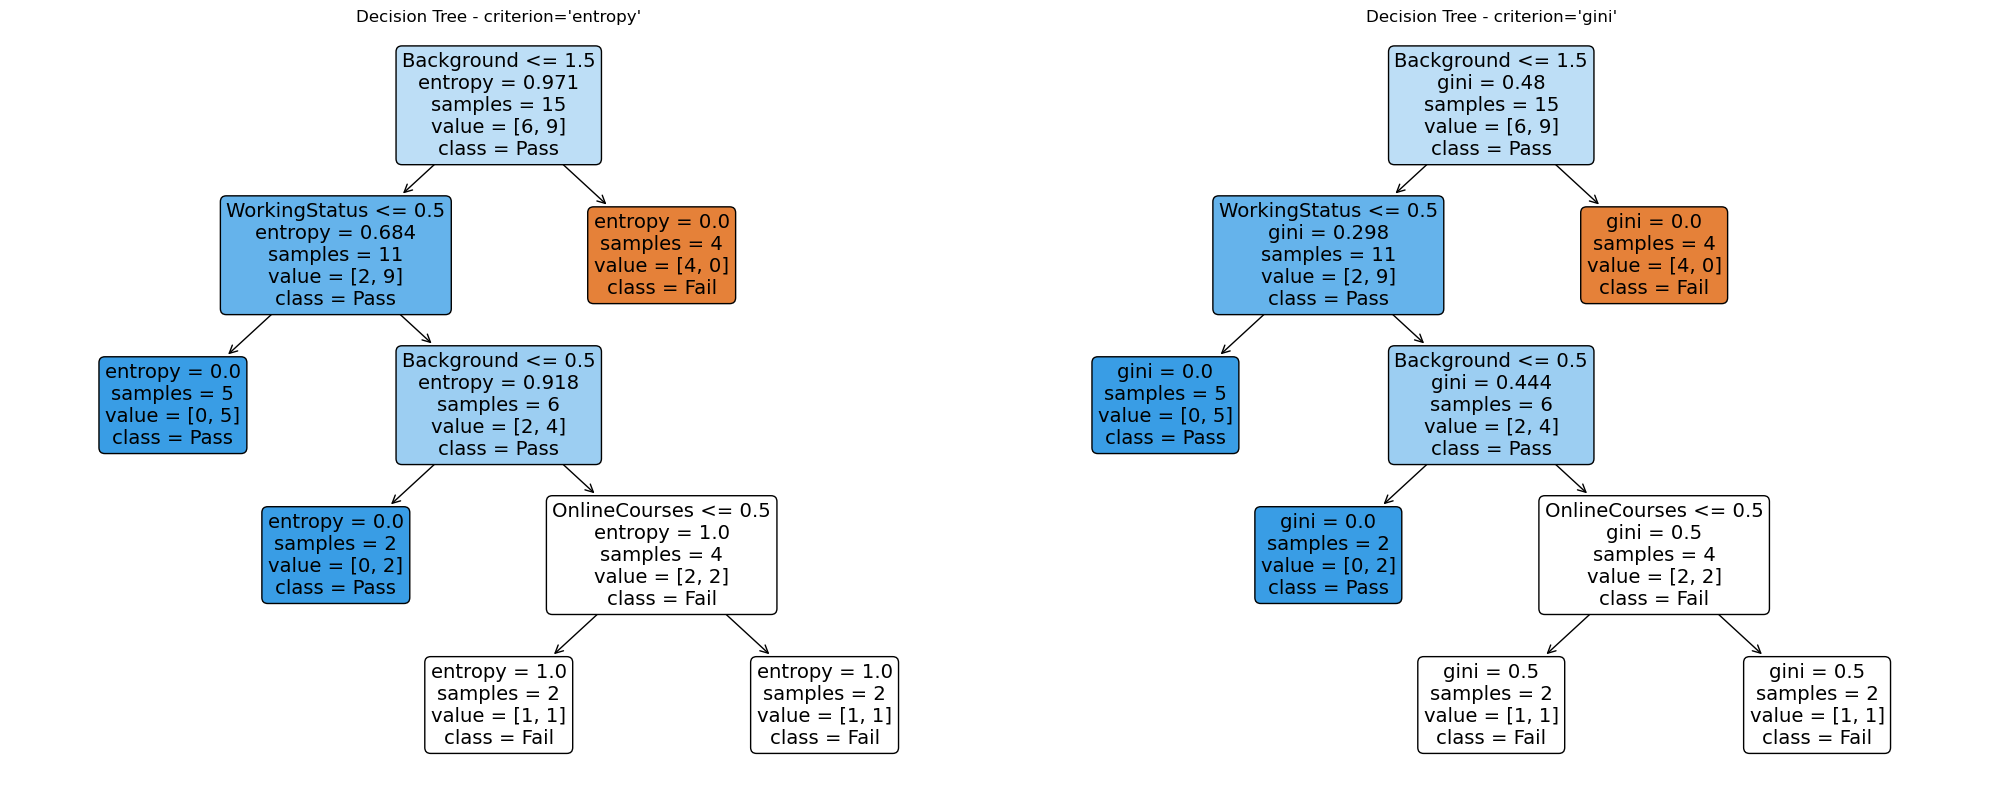

In [9]:
# ---------------------------------------------------------------------------
# 7. Visualisasi tree (untuk lampiran laporan)
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
plot_tree(clf_entropy, feature_names=feature_names, class_names=clf_entropy.classes_,
          filled=True, rounded=True, impurity=True, ax=axes[0])
axes[0].set_title("Decision Tree - criterion='entropy'")
plot_tree(clf_gini, feature_names=feature_names, class_names=clf_gini.classes_,
          filled=True, rounded=True, impurity=True, ax=axes[1])
axes[1].set_title("Decision Tree - criterion='gini'")
plt.tight_layout()
print("\nGambar tree tersimpan: decision_tree_entropy_vs_gini.png")
